---
title: "Лабораторна робота 4. Імовірнісний підхід до машинного навчання. Байєсівська класифікатор"
description:
  __Розпізнавання образів та комп'ютерний зір__
author: Denys Harahulia
date: "15.03.2026"
lang: ukr
format:
  html:
    code-fold: true
    toc: true # меню
    toc_float: # спливаюче меню  
      collapsed: true # авто
      number_sections: true
jupyter: python3
---

**Мета**: закріпити на практиці концепцію байєсівського вивода засобами мови Python

## Завдання для самостійної роботи 

1. Реалізувати наївний байєсівський класифікатор для свого варіанта (І завдання).
1. Реалізувати байєсівський класифікатор, попередньо змоделювавши дані згідно параметри кластерів у відповідності до свого варіанта (ІІ завдання).
 + Змінити знак коефіцієнта кореляції одного з кластерів. Повторити експеримент з класифікації. Що відбулося? вивести результати і прокоментувати
 + Модифікувати код на випадок трьох кластерів. Змоделювати відповідні дані і візуалізувати результати. ПРодемонструвати працездатність класифікатора.   
1. Дати відповіді на контрольні запитання.
1. Відправити результати роботи у файлі lab_4_StudentLastName.ipynb до віддаленого репозиторію на GіtHub.

1. Наївний байєсівський класифікатор

In [1]:
# Приклад реалізації наївного гаусовського байєсівського класифікатора

import numpy as np
import matplotlib.pyplot as plt


x_train = np.array([[17, 29], [44, 12], [47, 7], [18, 17], [30, 36], [6, 10], [38, 6], [10, 38], [41, 10], [42, 10]])
y_train = np.array([-1, 1, 1, -1, -1, -1, 1, -1, 1, 1])

mw1, ml1 = np.mean(x_train[y_train == 1], axis=0)
mw_1, ml_1 = np.mean(x_train[y_train == -1], axis=0)

# формула для обчислення дисперсії тут трохи інша 1/N*sum(...)
sw1, sl1 = np.var(x_train[y_train == 1], axis=0)
sw_1, sl_1 = np.var(x_train[y_train == -1], axis=0)

print('Середнє: ', mw1, ml1, mw_1, ml_1)
print('Дисперсії:', sw1, sl1, sw_1, sl_1)

x = [40, 10]  # довжина, ширина жука

a_1 = lambda x: -(x[0] - ml_1) ** 2 / (2 * sl_1) - (x[1] - mw_1) ** 2 / (2 * sw_1) # Перший класифікатор
a1 = lambda x: -(x[0] - ml1) ** 2 / (2 * sl1) - (x[1] - mw1) ** 2 / (2 * sw1) # Другий класифікатор
y = np.argmax([a_1(x), a1(x)]) # Обираємо максимум

print('Номер класу (0 - гусениця, 1 - божа корівка): ', y)


Середнє:  42.4 9.0 16.2 26.0
Дисперсії: 9.040000000000001 4.8 67.36 118.0
Номер класу (0 - гусениця, 1 - божа корівка):  0


2. Реалізувати байєсівський класифікатор

$\rho_1 = 0.8$, $\sigma_{x_1}^2 = 1.0$, $\mu_{x_1} = [0, -3]^T$, $\sigma_{y_1}^2 = 1.0$, $\mu_{y_1} = [0, -3]^T$

0


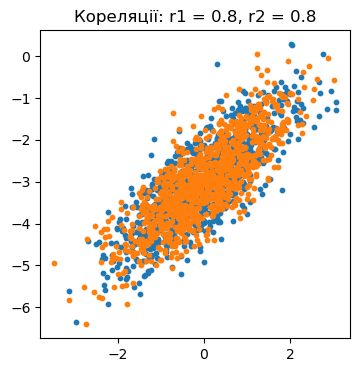

In [2]:
# Гауссівський баєсівський класифікатор

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# вихідні параметри розподілів двох класів
r1 = 0.8
D1 = 1.0
mean1 = [0, -3]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

r2 = 0.8
D2 = 1.0
mean2 = [0, -3]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

# моделювання навчальної вибірки
N = 1000
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T

# обчислення оцінок середнього та коваріаційних матриць
mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)

a = (x1.T - mm1).T
VV1 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

a = (x2.T - mm2).T
VV2 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

# модель гауссівського баєсівського класифікатора
Py1, L1 = 0.5, 1  # ймовірності появи класів
Py2, L2 = 1 - Py1, 1  # та величини штрафів невірної класифікації

b = lambda x, v, m, l, py: np.log(l * py) - 0.5 * (x - m) @ np.linalg.inv(v) @ (x - m).T - 0.5 * np.log(
    np.linalg.det(v))

x = np.array([0, -4])  # вхідний вектор у форматі (x, y)
a = np.argmax([b(x, VV1, mm1, L1, Py1), b(x, VV2, mm2, L2, Py2)])  # класифікатор
print(a)

# виведення графіків
plt.figure(figsize=(4, 4))
plt.title(f"Кореляції: r1 = {r1}, r2 = {r2}")
plt.scatter(x1[0], x1[1], s=10)
plt.scatter(x2[0], x2[1], s=10)
plt.show()

$\rho_1 = -0.8$, $\sigma_{x_1}^2 = 1.0$, $\mu_{x_1} = [0, -3]^T$, $\sigma_{y_1}^2 = 1.0$, $\mu_{y_1} = [0, -3]^T$

1


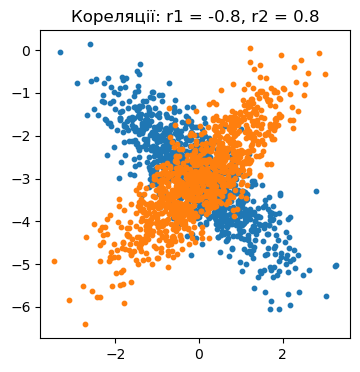

In [3]:
# Гауссівський баєсівський класифікатор

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# вихідні параметри розподілів двох класів
r1 = -0.8
D1 = 1.0
mean1 = [0, -3]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

r2 = 0.8
D2 = 1.0
mean2 = [0, -3]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

# моделювання навчальної вибірки
N = 1000
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T

# обчислення оцінок середнього та коваріаційних матриць
mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)

a = (x1.T - mm1).T
VV1 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

a = (x2.T - mm2).T
VV2 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

# модель гауссівського баєсівського класифікатора
Py1, L1 = 0.5, 1  # ймовірності появи класів
Py2, L2 = 1 - Py1, 1  # та величини штрафів невірної класифікації

b = lambda x, v, m, l, py: np.log(l * py) - 0.5 * (x - m) @ np.linalg.inv(v) @ (x - m).T - 0.5 * np.log(
    np.linalg.det(v))

x = np.array([0, -4])  # вхідний вектор у форматі (x, y)
a = np.argmax([b(x, VV1, mm1, L1, Py1), b(x, VV2, mm2, L2, Py2)])  # класифікатор
print(a)

# виведення графіків
plt.figure(figsize=(4, 4))
plt.title(f"Кореляції: r1 = {r1}, r2 = {r2}")
plt.scatter(x1[0], x1[1], s=10)
plt.scatter(x2[0], x2[1], s=10)
plt.show()

$\rho_1 = 0.8$, $\sigma_{x_1}^2 = 1.0$, $\mu_{x_1} = [0, -3]^T$, $\sigma_{y_1}^2 = 1.0$, $\mu_{y_1} = [0, -3]^T$
$\rho_2 = 0.7$, $\sigma_{x_2}^2 = 1.5$, $\mu_{x_2} = [-1, -2]^T$

0


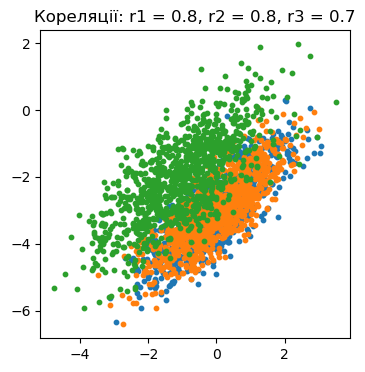

In [4]:
# Гауссівський баєсівський класифікатор

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# вихідні параметри розподілів двох класів
r1 = 0.8
D1 = 1.0
mean1 = [0, -3]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

r2 = 0.8
D2 = 1.0
mean2 = [0, -3]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

r3 = 0.7
D3 = 1.5
mean3 = [-1, -2]
V3 = [[D3, D3 * r3], [D3 * r3, D3]]
# моделювання навчальної вибірки
N = 1000
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T
x3 = np.random.multivariate_normal(mean3, V3, N).T

# обчислення оцінок середнього та коваріаційних матриць
mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)
mm3 = np.mean(x3.T, axis=0)

a = (x1.T - mm1).T
VV1 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

a = (x2.T - mm2).T
VV2 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

a = (x3.T - mm3).T
VV3 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

# модель гауссівського баєсівського класифікатора
Py1, L1 = 0.5, 1  # ймовірності появи класів
Py2, L2 = 1 - Py1, 1  # та величини штрафів невірної класифікації
Py3, L3 = 1 - Py2, 1 

b = lambda x, v, m, l, py: np.log(l * py) - 0.5 * (x - m) @ np.linalg.inv(v) @ (x - m).T - 0.5 * np.log(
    np.linalg.det(v))

x = np.array([0, -4])  # вхідний вектор у форматі (x, y)
a = np.argmax([b(x, VV1, mm1, L1, Py1), b(x, VV2, mm2, L2, Py2), b(x, VV3, mm3, L3, Py3)])  # класифікатор
print(a)

# виведення графіків
plt.figure(figsize=(4, 4))
plt.title(f"Кореляції: r1 = {r1}, r2 = {r2}, r3 = {r3}")
plt.scatter(x1[0], x1[1], s=10)
plt.scatter(x2[0], x2[1], s=10)
plt.scatter(x3[0], x3[1], s=10)
plt.show()